In [1]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
from scipy.stats import shapiro, levene, mannwhitneyu, ttest_ind, kstest

### Read the given dataset

In [2]:
df = pd.read_csv('/workspaces/codespaces-jupyter/ab_data.csv') #Read the a/b test user data
df.head()

,user_id,timestamp,group,landing_page,converted
0,851104,2017-01-21 22:11:48.556739,control,old_page,0
1,804228,2017-01-12 08:01:45.159739,control,old_page,0
2,661590,2017-01-11 16:55:06.154213,treatment,new_page,0
3,853541,2017-01-08 18:28:03.143765,treatment,new_page,0
4,864975,2017-01-21 01:52:26.210827,control,old_page,1


### Check for data validity

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 294478 entries, 0 to 294477
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   user_id       294478 non-null  int64 
 1   timestamp     294478 non-null  object
 2   group         294478 non-null  object
 3   landing_page  294478 non-null  object
 4   converted     294478 non-null  int64 
dtypes: int64(2), object(3)
memory usage: 11.2+ MB


In [4]:
# Check for Nulls
df.isnull().sum()

user_id         0
timestamp       0
group           0
landing_page    0
converted       0
dtype: int64

In [5]:
# Check for Duplicates
df.duplicated().sum()

np.int64(0)

In [6]:
# Check for duplicates in user_id field
df['user_id'].duplicated().sum()

np.int64(3894)

Conclusion - 
1. There are no null values in the dataset
2. There are no duplicates in the data at row level
3. There are duplicates in the user_id column

In [7]:
print("Group counts:\n", df['group'].value_counts())
print("\nConversion rate by group:\n", df.groupby('group')['converted'].mean().round(4))

Group counts:
 group
treatment    147276
control      147202
Name: count, dtype: int64

Conversion rate by group:
 group
control      0.1204
treatment    0.1189
Name: converted, dtype: float64


In [8]:
contamination = pd.crosstab(df['group'], df['landing_page'])
print(contamination)

mismatched = df[
    ((df['group'] == 'control') & (df['landing_page'] == 'new_page')) |
    ((df['group'] == 'treatment') & (df['landing_page'] == 'old_page'))
]
print(f"\nMismatched rows: {len(mismatched)} ({len(mismatched)/len(df)*100:.2f}% of data)")

landing_page  new_page  old_page
group                           
control           1928    145274
treatment       145311      1965

Mismatched rows: 3893 (1.32% of data)


In [9]:
df['timestamp'] = pd.to_datetime(df['timestamp'])
print("Start date:", df['timestamp'].min())
print("End date:", df['timestamp'].max())
print("Duration:", (df['timestamp'].max() - df['timestamp'].min()).days, "days")

Start date: 2017-01-02 13:42:05.378582
End date: 2017-01-24 13:41:54.460509
Duration: 21 days


The control set should have seen only the old_page and treatment set only new_page. This is not the current case.
1. 1.32% (3893) records are contaminated meaning in these cases the control have seen new_page and treatment have seen old_page
2. There are duplicates in the user_id field (3894) (Assignment Integrity Issue). This is nearly equal to the contamination count. We need to check for if these users have seen both the control and treatment pages and if that is the case, remove these users because we won't be able to determine if the conversion is through the influence of old or the new page
3. The experiemnt ran for 21 days which is a good signal as it covers 3 week cycle to track for seasonal effect. We will still calculate the power to determine the sample size and time required

### Remove the users with multiple experience

In [10]:
# Identify users with multiple assignments (exposed to both experiences)
duplicate_users = df['user_id'][df['user_id'].duplicated(keep=False)].unique()
print(f"Users with multiple assignments: {len(duplicate_users)}")

# Remove ALL rows for these users
df_clean = df[~df['user_id'].isin(duplicate_users)].copy()

# Also remove any remaining mismatched group/page rows (belt and suspenders)
df_clean = df_clean[
    ((df_clean['group'] == 'control') & (df_clean['landing_page'] == 'old_page')) |
    ((df_clean['group'] == 'treatment') & (df_clean['landing_page'] == 'new_page'))
].copy()

# Verify
print("Original shape:", df.shape)
print("Clean shape:", df_clean.shape)
print(f"Total rows removed: {len(df) - len(df_clean)}")
print("\nRemaining duplicate user_ids:", df_clean['user_id'].duplicated().sum())
print("\nGroup counts:\n", df_clean['group'].value_counts())
print("\nConversion rate by group:\n", df_clean.groupby('group')['converted'].mean().round(4))
print("\nContamination check:")
print(pd.crosstab(df_clean['group'], df_clean['landing_page']))

Users with multiple assignments: 3894
Original shape: (294478, 5)
Clean shape: (286690, 5)
Total rows removed: 7788

Remaining duplicate user_ids: 0

Group counts:
 group
treatment    143397
control      143293
Name: count, dtype: int64

Conversion rate by group:
 group
control      0.1202
treatment    0.1187
Name: converted, dtype: float64

Contamination check:
landing_page  new_page  old_page
group                           
control              0    143293
treatment       143397         0


The control and treatment groups have ~143K users which can be considered balance

### Hypothesis

##### Experiment Context
The product team redesigned the landing page (new_page) with the goal of 
increasing user conversion. We run a one-tailed test since the hypothesis 
is directional — we only care if the new page *increases* conversion.

##### Metric
**Primary metric:** Conversion Rate = (users who converted) / (total users in group)
This is a proportion, not a continuous variable — statistical test choice follows from this.

##### Hypotheses
- **H0 (Null):** Conversion rate of treatment ≤ Conversion rate of control
  - p_treatment ≤ p_control
- **H1 (Alternative):** Conversion rate of treatment > Conversion rate of control  
  - p_treatment > p_control

##### Decision Rule
- Significance level α = 0.05
- If p-value < 0.05 → Reject H0 → New page performs significantly better
- If p-value ≥ 0.05 → Fail to reject H0 → No evidence new page is better

##### Why not a t-test?
The outcome variable (converted) is binary (0/1). The correct test for comparing 
two proportions is a Z-test for proportions, not a t-test on aggregated daily rates.
Aggregating to daily rates reduces n from ~290K users to ~23 days, 
losing statistical power and misrepresenting the unit of analysis.

### Power Analysis 
To conduct power analysis we require the below:
1. Baseline rate (p_control) = 0.1202 (From the above analysis)
2. MDE = 0.02 (Ideally decided after discussing with Project manager, engineering team and the data analyst)
3. α = 0.05 (one-tailed)
4. Power (1-β) = 0.80

#### How MDE is decided?
There are three common approaches in industry:
1. Business viability threshold
The PM asks: "What's the minimum lift that justifies the engineering cost, design cost, and risk of this change?" If the new page costs 2 weeks of eng time, a 0.1% lift probably doesn't justify it. A 1-2pp lift might. This is the most common starting point.
2. Historical baseline from past experiments
Teams that run experiments regularly build up a library of past lifts. If your last 10 landing page tests moved conversion by 0.5–2pp, you design future experiments to detect in that range. You don't design for effects you've never seen.
3. Revenue or impact modeling
Work backwards from business impact. At 12% baseline and say 1M monthly users, a 1pp lift = 10,000 extra conversions/month. If each conversion is worth $50, that's $500K/month. Is that worth detecting? Almost certainly yes. This grounds the MDE in actual dollars, not intuition.

In [11]:
from statsmodels.stats.power import NormalIndPower
from statsmodels.stats.proportion import proportion_effectsize

# Baseline conversion rate from clean data
p_control = df_clean[df_clean['group'] == 'control']['converted'].mean()
print(f"Baseline conversion rate: {p_control:.4f}")

# --- Scenario 1: MDE = 2 percentage points (realistic) ---
mde_realistic = 0.02
p_treatment_realistic = p_control + mde_realistic
effect_size_realistic = proportion_effectsize(p_treatment_realistic, p_control)

# --- Scenario 2: MDE = 0.5 percentage points (aggressive) --- For demo purpose only
mde_aggressive = 0.005
p_treatment_aggressive = p_control + mde_aggressive
effect_size_aggressive = proportion_effectsize(p_treatment_aggressive, p_control)

# Sample size calculation
analysis = NormalIndPower()

n_realistic = analysis.solve_power(
    effect_size=effect_size_realistic,
    alpha=0.05,
    power=0.80,
    alternative='larger'   # one-tailed
)

n_aggressive = analysis.solve_power(
    effect_size=effect_size_aggressive,
    alpha=0.05,
    power=0.80,
    alternative='larger'
)

print(f"\n--- MDE = 2pp (realistic) ---")
print(f"Expected treatment rate: {p_treatment_realistic:.4f}")
print(f"Effect size (Cohen's h): {effect_size_realistic:.4f}")
print(f"Required sample size per group: {int(np.ceil(n_realistic)):,}")

print(f"\n--- MDE = 0.5pp (aggressive) ---")
print(f"Expected treatment rate: {p_treatment_aggressive:.4f}")
print(f"Effect size (Cohen's h): {effect_size_aggressive:.4f}")
print(f"Required sample size per group: {int(np.ceil(n_aggressive)):,}")

# How much data do we actually have?
n_control = df_clean[df_clean['group'] == 'control'].shape[0]
n_treatment = df_clean[df_clean['group'] == 'treatment'].shape[0]

print(f"\n--- Actual data collected ---")
print(f"Control group: {n_control:,}")
print(f"Treatment group: {n_treatment:,}")

print(f"\n--- Verdict ---")
print(f"Sufficient for 2pp MDE? {'✅ Yes' if n_control >= n_realistic else '❌ No'}")
print(f"Sufficient for 0.5pp MDE? {'✅ Yes' if n_control >= n_aggressive else '❌ No'}")

Baseline conversion rate: 0.1202

--- MDE = 2pp (realistic) ---
Expected treatment rate: 0.1402
Effect size (Cohen's h): 0.0595
Required sample size per group: 3,496

--- MDE = 0.5pp (aggressive) ---
Expected treatment rate: 0.1252
Effect size (Cohen's h): 0.0152
Required sample size per group: 53,227

--- Actual data collected ---
Control group: 143,293
Treatment group: 143,397

--- Verdict ---
Sufficient for 2pp MDE? ✅ Yes
Sufficient for 0.5pp MDE? ✅ Yes


As you can see in the above scenario, how sample size changes based on the MDE value. 
In a company setting, we prepare Sensitivity table with required sample size for different MDE

This is presented to the project manager and depending on the available sample group and other business justifications, MDE is decided

But for big companies like Google, Microsoft there problem is not that we don't have enough sample but instead how long do we want to run the experiment.

In such cases, even 0.1pp increment can worth millions. Now consider that with 0.001 MDE the required sample size is ~130K per group. These company have millions of user traffic everyday which means we might hit the required sample size within 2 days. But this doesn't mean we stop the experiment.

Even if you hit your sample size in 2 days, most mature experimentation teams enforce a minimum 1-2 week runtime to capture:
1. Weekday vs weekend behaviour differences
2. Novelty effect decay — users behave differently when they first see something new vs after a few days
3. Weekly seasonality in booking/travel behaviour (huge at Agoda specifically)

In [12]:
from statsmodels.stats.proportion import proportions_ztest, proportion_confint

# Get conversions and total users per group
control = df_clean[df_clean['group'] == 'control']
treatment = df_clean[df_clean['group'] == 'treatment']

n_control = len(control)
n_treatment = len(treatment)
conv_control = control['converted'].sum()
conv_treatment = treatment['converted'].sum()

p_control = conv_control / n_control
p_treatment = conv_treatment / n_treatment

print("=== Conversion Summary ===")
print(f"Control:   {conv_control:,} / {n_control:,} = {p_control:.4f} ({p_control*100:.2f}%)")
print(f"Treatment: {conv_treatment:,} / {n_treatment:,} = {p_treatment:.4f} ({p_treatment*100:.2f}%)")
print(f"Observed difference (treatment - control): {(p_treatment - p_control)*100:.4f}pp")

# One-tailed Z-test (alternative='larger' = testing if treatment > control)
count = np.array([conv_treatment, conv_control])
nobs = np.array([n_treatment, n_control])

z_stat, p_value = proportions_ztest(count, nobs, alternative='larger')

print("\n=== Z-Test Results ===")
print(f"Z-statistic: {z_stat:.4f}")
print(f"P-value (one-tailed): {p_value:.4f}")
print(f"Significance level (α): 0.05")

print("\n=== Decision ===")
if p_value < 0.05:
    print("✅ Reject H0 — Treatment conversion rate is significantly higher than control")
else:
    print("❌ Fail to reject H0 — No significant evidence that new page performs better")

=== Conversion Summary ===
Control:   17,220 / 143,293 = 0.1202 (12.02%)
Treatment: 17,025 / 143,397 = 0.1187 (11.87%)
Observed difference (treatment - control): -0.1447pp

=== Z-Test Results ===
Z-statistic: -1.1945
P-value (one-tailed): 0.8839
Significance level (α): 0.05

=== Decision ===
❌ Fail to reject H0 — No significant evidence that new page performs better


### Effect Size and Confidence interval

1. P-value answers: "Is the effect real or could it be random chance?"
2. Confidence Interval answers: "What is the plausible range of the true effect?"
3. Effect size answers: "How big is the effect in practical terms?"

The Confidence Interval adds three things the p-value cannot tell you:
1. The range of plausible true effects
2. Precision of your estimate - A narrow CI means the experiment was well-powered and the estimate is reliable. A wide CI means uncertainty is high.
3. The upper bound is what matters for the business decision - Even if the point estimate is -0.14pp, the business cares about the upper bound of the CI. If the upper bound is +0.3pp, there's still a plausible world where the new page is slightly better.

Effect size adds:
The standardised magnitude of the difference — independent of sample size. This is critical because with 143K users, even a 0.01pp difference could be statistically significant. Effect size tells you whether the difference is meaningful in the real world, not just detectable statistically.

In [13]:
from scipy.stats import norm

# ── Conversion rates ──────────────────────────────────────────
p_control   = conv_control   / n_control
p_treatment = conv_treatment / n_treatment
diff        = p_treatment - p_control

print("=== Observed Difference ===")
print(f"Control rate:       {p_control:.4f}  ({p_control*100:.2f}%)")
print(f"Treatment rate:     {p_treatment:.4f}  ({p_treatment*100:.2f}%)")
print(f"Difference (T - C): {diff*100:.4f}pp")

# ── Confidence Interval on the difference ────────────────────
# Standard error of the difference (unpooled — for CI we don't assume H0)
se_diff = np.sqrt(
    (p_treatment * (1 - p_treatment) / n_treatment) +
    (p_control   * (1 - p_control)   / n_control)
)

z_critical = norm.ppf(0.975)  # 1.96 for 95% CI (two-sided bounds on the estimate)

ci_lower = diff - z_critical * se_diff
ci_upper = diff + z_critical * se_diff

print("\n=== 95% Confidence Interval on Difference (T - C) ===")
print(f"SE of difference:   {se_diff:.6f}")
print(f"CI lower bound:     {ci_lower*100:.4f}pp")
print(f"CI upper bound:     {ci_upper*100:.4f}pp")
print(f"Interpretation:     We are 95% confident the true difference lies between "
      f"{ci_lower*100:.4f}pp and {ci_upper*100:.4f}pp")

# ── Effect Size (Cohen's h) ───────────────────────────────────
# Cohen's h is the standard effect size measure for proportions
cohen_h = 2 * np.arcsin(np.sqrt(p_treatment)) - 2 * np.arcsin(np.sqrt(p_control))

print("\n=== Effect Size (Cohen's h) ===")
print(f"Cohen's h: {cohen_h:.4f}")

if abs(cohen_h) < 0.2:
    magnitude = "Small (negligible practical impact)"
elif abs(cohen_h) < 0.5:
    magnitude = "Medium"
else:
    magnitude = "Large"

print(f"Magnitude: {magnitude}")

# ── Business significance check ───────────────────────────────
mde = 0.02  # our pre-committed MDE
print("\n=== Practical Significance Check ===")
print(f"Pre-committed MDE:  {mde*100:.2f}pp")
print(f"Observed effect:    {diff*100:.4f}pp")
print(f"CI upper bound:     {ci_upper*100:.4f}pp")

if ci_upper * 100 < mde * 100:
    print("✅ Even the upper bound of the CI is below MDE — "
          "new page cannot deliver meaningful lift under any plausible scenario")
else:
    print("⚠️  Upper bound exceeds MDE — some uncertainty remains about practical significance")

=== Observed Difference ===
Control rate:       0.1202  (12.02%)
Treatment rate:     0.1187  (11.87%)
Difference (T - C): -0.1447pp

=== 95% Confidence Interval on Difference (T - C) ===
SE of difference:   0.001211
CI lower bound:     -0.3821pp
CI upper bound:     0.0927pp
Interpretation:     We are 95% confident the true difference lies between -0.3821pp and 0.0927pp

=== Effect Size (Cohen's h) ===
Cohen's h: -0.0045
Magnitude: Small (negligible practical impact)

=== Practical Significance Check ===
Pre-committed MDE:  2.00pp
Observed effect:    -0.1447pp
CI upper bound:     0.0927pp
✅ Even the upper bound of the CI is below MDE — new page cannot deliver meaningful lift under any plausible scenario


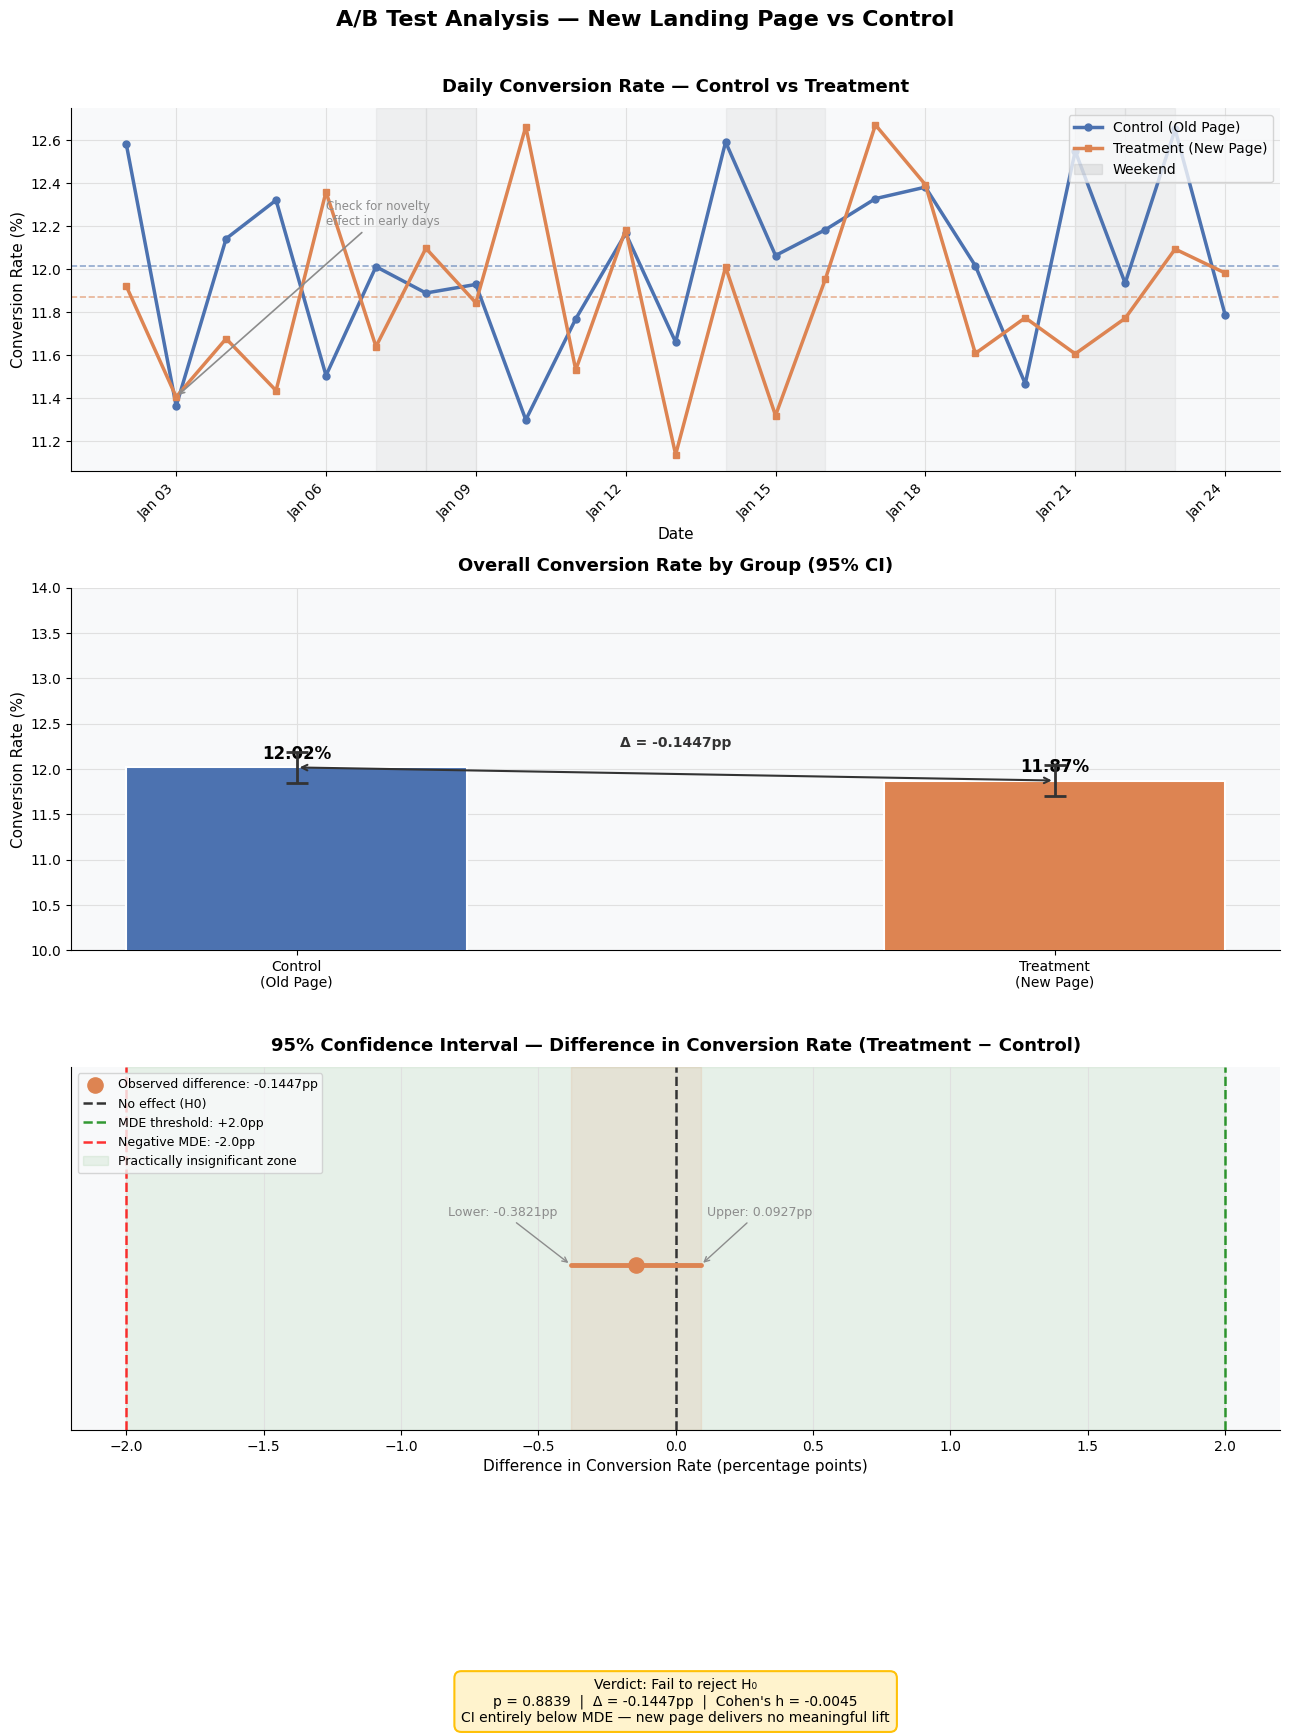

✅ Plot saved as ab_test_analysis.png


In [15]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')

# ── Colour palette ─────────────────────────────────────────────
COLOR_CONTROL   = '#4C72B0'
COLOR_TREATMENT = '#DD8452'
COLOR_NEUTRAL   = '#8C8C8C'
COLOR_BG        = '#F8F9FA'

plt.rcParams.update({
    'font.family'     : 'DejaVu Sans',
    'axes.spines.top' : False,
    'axes.spines.right': False,
    'axes.facecolor'  : COLOR_BG,
    'figure.facecolor': 'white',
    'axes.grid'       : True,
    'grid.color'      : '#E0E0E0',
    'grid.linewidth'  : 0.8,
})

fig, axes = plt.subplots(3, 1, figsize=(13, 18))
fig.suptitle('A/B Test Analysis — New Landing Page vs Control',
             fontsize=16, fontweight='bold', y=0.98)

# ══════════════════════════════════════════════════════════════
# PLOT 1: Daily Conversion Rate Trend
# ══════════════════════════════════════════════════════════════
ax1 = axes[0]

# Build daily conversion rates
df_clean['date'] = pd.to_datetime(df_clean['timestamp']).dt.date

daily = (
    df_clean
    .groupby(['date', 'group'])['converted']
    .agg(['sum', 'count'])
    .reset_index()
)
daily.columns = ['date', 'group', 'conversions', 'total']
daily['rate'] = daily['conversions'] / daily['total']
daily['date'] = pd.to_datetime(daily['date'])

control_daily   = daily[daily['group'] == 'control'].sort_values('date')
treatment_daily = daily[daily['group'] == 'treatment'].sort_values('date')

ax1.plot(control_daily['date'],   control_daily['rate'] * 100,
         color=COLOR_CONTROL,   linewidth=2.5, marker='o',
         markersize=5, label='Control (Old Page)',   zorder=3)

ax1.plot(treatment_daily['date'], treatment_daily['rate'] * 100,
         color=COLOR_TREATMENT, linewidth=2.5, marker='s',
         markersize=5, label='Treatment (New Page)', zorder=3)

# Overall average reference lines
ax1.axhline(p_control   * 100, color=COLOR_CONTROL,
            linestyle='--', linewidth=1.2, alpha=0.6)
ax1.axhline(p_treatment * 100, color=COLOR_TREATMENT,
            linestyle='--', linewidth=1.2, alpha=0.6)

# Weekend shading
for date in pd.date_range(control_daily['date'].min(),
                           control_daily['date'].max()):
    if date.weekday() >= 5:
        ax1.axvspan(date, date + pd.Timedelta(days=1),
                    alpha=0.08, color='grey', zorder=0)

ax1.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
ax1.xaxis.set_major_locator(mdates.DayLocator(interval=3))
plt.setp(ax1.xaxis.get_majorticklabels(), rotation=45, ha='right')

ax1.set_title('Daily Conversion Rate — Control vs Treatment',
              fontsize=13, fontweight='bold', pad=12)
ax1.set_ylabel('Conversion Rate (%)', fontsize=11)
ax1.set_xlabel('Date', fontsize=11)
ax1.legend(fontsize=10, loc='upper right')

# Novelty effect annotation
ax1.annotate('Check for novelty\neffect in early days',
             xy=(control_daily['date'].iloc[1], 
                 treatment_daily['rate'].iloc[1] * 100),
             xytext=(control_daily['date'].iloc[4],
                     treatment_daily['rate'].iloc[1] * 100 + 0.8),
             fontsize=8.5, color=COLOR_NEUTRAL,
             arrowprops=dict(arrowstyle='->', color=COLOR_NEUTRAL,
                             lw=1.2))

weekend_patch = mpatches.Patch(color='grey', alpha=0.15,
                                label='Weekend')
ax1.legend(handles=[
    plt.Line2D([0], [0], color=COLOR_CONTROL,   linewidth=2.5,
               marker='o', markersize=5, label='Control (Old Page)'),
    plt.Line2D([0], [0], color=COLOR_TREATMENT, linewidth=2.5,
               marker='s', markersize=5, label='Treatment (New Page)'),
    weekend_patch
], fontsize=10, loc='upper right')

# ══════════════════════════════════════════════════════════════
# PLOT 2: Overall Conversion Rate Bar Chart with Error Bars
# ══════════════════════════════════════════════════════════════
ax2 = axes[1]

groups      = ['Control\n(Old Page)', 'Treatment\n(New Page)']
rates       = [p_control * 100, p_treatment * 100]
colors      = [COLOR_CONTROL, COLOR_TREATMENT]

# 95% CI for each individual proportion
ci_control_low,   ci_control_high   = proportion_confint(
    conv_control,   n_control,   alpha=0.05, method='wilson')
ci_treatment_low, ci_treatment_high = proportion_confint(
    conv_treatment, n_treatment, alpha=0.05, method='wilson')

errors_low  = [
    (p_control   - ci_control_low)   * 100,
    (p_treatment - ci_treatment_low) * 100
]
errors_high = [
    (ci_control_high   - p_control)   * 100,
    (ci_treatment_high - p_treatment) * 100
]

bars = ax2.bar(groups, rates, color=colors, width=0.45,
               edgecolor='white', linewidth=1.5, zorder=3)

ax2.errorbar(groups, rates,
             yerr=[errors_low, errors_high],
             fmt='none', color='#333333',
             capsize=8, capthick=2, elinewidth=2, zorder=4)

# Value labels on bars
for bar, rate in zip(bars, rates):
    ax2.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + 0.05,
             f'{rate:.2f}%',
             ha='center', va='bottom',
             fontsize=12, fontweight='bold')

ax2.set_title('Overall Conversion Rate by Group (95% CI)',
              fontsize=13, fontweight='bold', pad=12)
ax2.set_ylabel('Conversion Rate (%)', fontsize=11)
# ax2.set_ylim(0, max(rates) * 1.25)
ax2.set_ylim(10, 14)  # Zoom y-axis to show error bars clearly

# Difference annotation
ax2.annotate('',
             xy=(1, p_treatment * 100),
             xytext=(0, p_control * 100),
             arrowprops=dict(arrowstyle='<->', color='#333333',
                             lw=1.5))
ax2.text(0.5, (p_control + p_treatment) / 2 * 100 + 0.3,
         f'Δ = {(p_treatment - p_control)*100:.4f}pp',
         ha='center', fontsize=10, color='#333333',
         fontweight='bold')

# ══════════════════════════════════════════════════════════════
# PLOT 3: Confidence Interval of the Difference
# ══════════════════════════════════════════════════════════════
ax3 = axes[2]

# CI on the difference
diff_pp      = (p_treatment - p_control) * 100
ci_lower_pp  = ci_lower * 100
ci_upper_pp  = ci_upper * 100
mde_pp       = mde_realistic * 100

# Horizontal CI line
ax3.plot([ci_lower_pp, ci_upper_pp], [0, 0],
         color=COLOR_TREATMENT, linewidth=3.5,
         solid_capstyle='round', zorder=3)

# Point estimate
ax3.scatter([diff_pp], [0],
            color=COLOR_TREATMENT, s=120, zorder=5,
            label=f'Observed difference: {diff_pp:.4f}pp')

# Zero line — no effect
ax3.axvline(0, color='#333333', linewidth=1.8,
            linestyle='--', label='No effect (H0)', zorder=2)

# MDE lines
ax3.axvline(mde_pp, color='green', linewidth=1.8,
            linestyle='--', alpha=0.8,
            label=f'MDE threshold: +{mde_pp}pp', zorder=2)
ax3.axvline(-mde_pp, color='red', linewidth=1.8,
            linestyle='--', alpha=0.8,
            label=f'Negative MDE: -{mde_pp}pp', zorder=2)

# Shaded regions
ax3.axvspan(ci_lower_pp, ci_upper_pp,
            alpha=0.12, color=COLOR_TREATMENT, zorder=1)
ax3.axvspan(-mde_pp, mde_pp,
            alpha=0.07, color='green',
            label='Practically insignificant zone', zorder=0)

# CI bound annotations
ax3.annotate(f'Lower: {ci_lower_pp:.4f}pp',
             xy=(ci_lower_pp, 0),
             xytext=(ci_lower_pp - 0.05, 0.3),
             fontsize=9, ha='right', color=COLOR_NEUTRAL,
             arrowprops=dict(arrowstyle='->', color=COLOR_NEUTRAL))
ax3.annotate(f'Upper: {ci_upper_pp:.4f}pp',
             xy=(ci_upper_pp, 0),
             xytext=(ci_upper_pp + 0.02, 0.3),
             fontsize=9, ha='left', color=COLOR_NEUTRAL,
             arrowprops=dict(arrowstyle='->', color=COLOR_NEUTRAL))

ax3.set_title('95% Confidence Interval — Difference in Conversion Rate (Treatment − Control)',
              fontsize=13, fontweight='bold', pad=12)
ax3.set_xlabel('Difference in Conversion Rate (percentage points)', fontsize=11)
ax3.set_yticks([])
ax3.set_ylim(-1, 1.2)
ax3.legend(fontsize=9, loc='upper left')

# Verdict box
verdict = (f"Verdict: Fail to reject H₀\n"
           f"p = 0.8839  |  Δ = {diff_pp:.4f}pp  |  "
           f"Cohen's h = {cohen_h:.4f}\n"
           f"CI entirely below MDE — new page delivers no meaningful lift")

ax3.text(0.5, -0.75, verdict,
         transform=ax3.transAxes,
         fontsize=10, ha='center', va='center',
         bbox=dict(boxstyle='round,pad=0.5',
                   facecolor='#FFF3CD',
                   edgecolor='#FFC107',
                   linewidth=1.5))

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.savefig('ab_test_analysis.png', dpi=150,
            bbox_inches='tight', facecolor='white')
plt.show()
print("✅ Plot saved as ab_test_analysis.png")

In [16]:
# ── Summary statistics ─────────────────────────────────────────
total_users     = n_control + n_treatment
monthly_traffic = total_users  # approximation for framing
lost_conv_worst = abs(ci_lower) * monthly_traffic

print("=" * 65)
print("        A/B TEST READOUT — NEW LANDING PAGE EXPERIMENT")
print("=" * 65)

print("""
EXPERIMENT SUMMARY
──────────────────────────────────────────────────────────────
Hypothesis : New landing page increases conversion rate
Test type  : One-tailed Z-test for proportions
Duration   : 21 days (Jan 02 – Jan 24, 2017)
""")

print(f"{'Metric':<35} {'Control':>12} {'Treatment':>12}")
print("-" * 60)
print(f"{'Users':<35} {n_control:>12,} {n_treatment:>12,}")
print(f"{'Conversions':<35} {conv_control:>12,} {conv_treatment:>12,}")
print(f"{'Conversion Rate':<35} {p_control*100:>11.2f}% {p_treatment*100:>11.2f}%")
print(f"{'Difference (Treatment - Control)':<35} {diff*100:>11.4f}pp {'':>12}")
print(f"{'95% CI on Difference':<35} {'['+f'{ci_lower*100:.4f}pp'+',':<12} {f'{ci_upper*100:.4f}pp'+']':>12}")
print(f"{'Z-statistic':<35} {z_stat:>12.4f} {'':>12}")
print(f"{'P-value (one-tailed)':<35} {p_value:>12.4f} {'':>12}")
print(f"{'Cohen\'s h (effect size)':<35} {cohen_h:>12.4f} {'':>12}")
print(f"{'Pre-committed MDE':<35} {'2.00pp':>12} {'':>12}")

print("""
STATISTICAL VERDICT
──────────────────────────────────────────────────────────────
❌ Fail to reject H0
   p = 0.8839 >> α = 0.05
   No statistically significant evidence that the new page
   improves conversion rate.
""")

print(f"""PRACTICAL SIGNIFICANCE
──────────────────────────────────────────────────────────────
❌ No practical significance detected
   Observed effect   : {diff*100:.4f}pp (treatment is worse)
   CI upper bound    : {ci_upper*100:.4f}pp
   Pre-committed MDE : 2.00pp

   Even under the most optimistic statistical scenario,
   the new page delivers only {ci_upper/mde_realistic*100:.1f}% of the minimum
   lift required to justify shipping.
""")

print(f"""BUSINESS RISK OF SHIPPING ANYWAY
──────────────────────────────────────────────────────────────
   Worst case (CI lower bound) : -{abs(ci_lower)*100:.4f}pp conversion loss
   Estimated lost conversions  : ~{int(lost_conv_worst):,} per experiment period
   Direction of observed effect: Treatment is WORSE than control

   Shipping the new page carries measurable downside risk
   with no statistically or practically credible upside.
""")

print("""RECOMMENDATION
──────────────────────────────────────────────────────────────
🚫 DO NOT SHIP the new landing page globally.

   This is a definitive null result — not an underpowered one.
   With 143K+ users per group, the experiment had sufficient
   power to detect a 2pp lift. The absence of signal here is
   a signal in itself.

   A well-designed experiment that gives a clean null result
   is a success — it prevents shipping a change that does
   not work and redirects resources toward higher-impact work.
""")

print("""NEXT STEPS
──────────────────────────────────────────────────────────────
1. SEGMENT ANALYSIS (immediate)
   Run pre-specified segment breakdown across:
   → Device type      (mobile vs desktop)
   → User type        (new vs returning)
   → Geography        (top 5 markets)
   → Traffic source   (organic vs paid)

   If any segment shows consistent directional improvement
   above MDE, design a targeted follow-up experiment for
   that segment specifically.

2. QUALITATIVE RESEARCH (2 weeks)
   Run user testing sessions on the new page to identify
   friction points. Understand WHY it underperformed —
   copy, layout, CTA placement, page speed.

3. REDESIGN HYPOTHESIS (4 weeks)
   Use segment findings and qualitative insights to form
   a stronger, more targeted hypothesis before the next
   experiment. Define a new MDE based on what the segment
   analysis reveals.

4. FOLLOW-UP EXPERIMENT (6-8 weeks)
   Design the next experiment with the revised hypothesis,
   pre-specified segments, and appropriate sample size
   for the target segment's traffic volume.
""")

print("=" * 65)
print("   CONCLUSION: Old page retained. Experiment closed.")
print("=" * 65)

        A/B TEST READOUT — NEW LANDING PAGE EXPERIMENT

EXPERIMENT SUMMARY
──────────────────────────────────────────────────────────────
Hypothesis : New landing page increases conversion rate
Test type  : One-tailed Z-test for proportions
Duration   : 21 days (Jan 02 – Jan 24, 2017)

Metric                                   Control    Treatment
------------------------------------------------------------
Users                                    143,293      143,397
Conversions                               17,220       17,025
Conversion Rate                           12.02%       11.87%
Difference (Treatment - Control)        -0.1447pp             
95% CI on Difference                [-0.3821pp,     0.0927pp]
Z-statistic                              -1.1945             
P-value (one-tailed)                      0.8839             
Cohen's h (effect size)                  -0.0045             
Pre-committed MDE                         2.00pp             

STATISTICAL VERDICT
──────────